<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/HMNC_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import các thư viện sau:

numpy (as np)

pandas

RandomForestClassifier from sklearn.ensemble

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Bước 1 Load dataset

Đọc dữ liệu

Đọc data từ github


In [9]:
#url = "https://raw.githubusercontent.com/user/repo/main/home.csv"
url ="https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/refs/heads/main/23_HOMES.csv"
df = pd.read_csv(url)
df.head()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2


# **Kích thước dữ liệu**

In [11]:
df.shape

(40, 9)

# **Bước 2.Tiền xử lý dữ liệu**

# 2.1 kiểm tra giá trị null


In [12]:
df.isnull().sum()

,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,0
Baths_full,0


# 2.2 Kiểm tra outline
Kiểm tra bằng boxplot

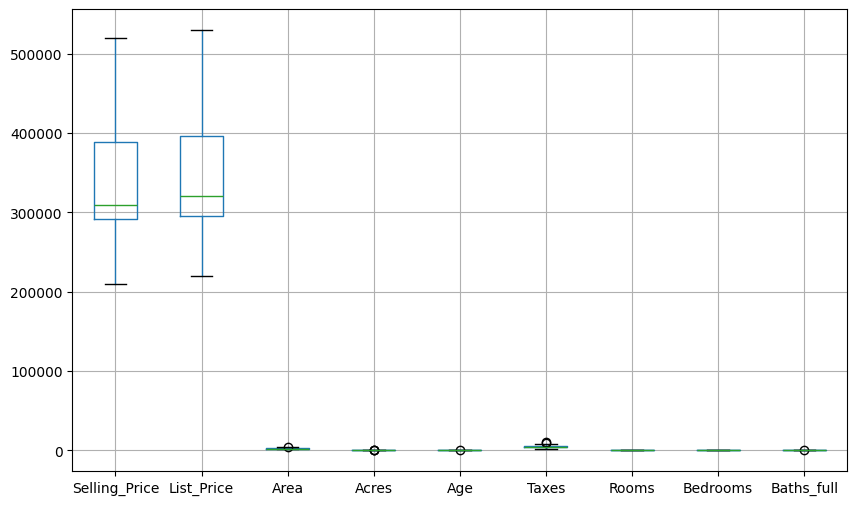

In [15]:
df.boxplot(figsize=(10,6))
plt.show()

# Age = 69 có thể là outlier

# Acres = 3.6 khá lớn

# Loại **Outline**

In [16]:
df = df[df["Age"] < 60]

# **Phân tích tương quan**

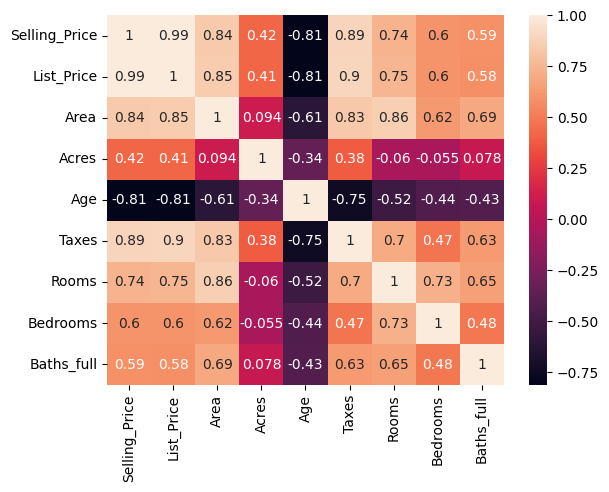

In [18]:


corr = df.corr()

sns.heatmap(corr, annot=True)
plt.show()

# Nhận xét quan trọng

Các biến có tương quan cao với Selling_Price thường là:

List_Price

Area

Taxes **bold text**

# **Bước 2 Chọn Feature và Target**

 Vhúng ta định nghĩa các tham số sau:

**X** as the Ma trận thuộc tính (data of my_data)

**Y **as the Vector
# - Selling_price **(target)**
# - Feature (List_Price, Area, Acres, Age, Taxes, Rooms, Bedrooms, Baths_full)


In [21]:
# Lệnh drop sẽ bỏ cột 'Selling_Price' đi, lấy tất cả các cột còn lại làm X
X = df.drop(columns=['Selling_Price'])
Y = df['Selling_Price']
target = "Selling_Price"
features = [col for col in df.columns if col != target]
print("Target: ", target)
print("Feature :", features)



Target:  Selling_Price
Feature : ['List_Price', 'Area', 'Acres', 'Age', 'Taxes', 'Rooms', 'Bedrooms', 'Baths_full']


**Bước 3 - Chia dữ liệu**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)